# Comparing Air Quality in the East Tower and West Tower

The following charts the PM<sub>2.5</sub> values minute-by-minute, over a one week period in the following areas of the building:
- West Tower 2nd Floor Hallway (October 29, 2024 - November 4, 2024)
- West Tower 5th Floor Hallway (November 5, 2024 - November 11, 2024)
- East Tower 5th Floor Hallway (November 12, 2024 - November 18, 2024)

Note that these are Tuesday-Monday weeks, chosen as Mondays are sometimes observed to be the most polluted day of the week, and appears more correlated to the preceding Sunday. Whereas by Tuesday, things tend to have calmed down

In [1]:
import datetime

import matplotlib as mpl
import matplotlib.colors as colors
import pandas as pd
from typing import NamedTuple, Tuple

Note = NamedTuple("Note", [("x", datetime.datetime), ("y", float), ("s", str)])

aqi_edges = [0, 51, 101, 151, 201, 301, 501]
aqi_colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
aqi_cmap, aqi_norm = colors.from_levels_and_colors(aqi_edges, aqi_colors)
color_by_field = {
    "AQI": mpl.colormaps["Pastel1"].colors[8],
    "L2_Patio": mpl.colormaps["Pastel1"].colors[1],
    "L2_Unit_210": mpl.colormaps["Pastel1"].colors[3],
    "L2_West_Hallway": mpl.colormaps["Pastel1"].colors[6]
}
    
def display_data(df_aqi_by_time: pd.DataFrame, notes: list[Note]=[]) -> pd.DataFrame:
    color = [color_by_field[field] for field in list(df_aqi_by_time)]
    ax = df_aqi_by_time.plot(ylabel="AQI", color=color, ylim=(-10, 500))
    for field in df_aqi_by_time:
        df_aqi_by_time.reset_index().plot.scatter(
            ["Time"], [field],
            c=field, norm=aqi_norm, cmap=aqi_cmap, colorbar=False,
            marker="o", s=8,
            xlabel="Time", ylabel="AQI", ax=ax
        )
    for note in notes:
        ax.text(*note)


In [2]:
%run "Common.ipynb"

Time                                   \
                                       min                       max  count   
Model     Device                                                              
M10+      01     2024-08-18 17:00:00+08:00 2024-11-17 15:00:00+08:00   1821   
          02     2024-08-18 17:00:00+08:00 2024-08-24 14:00:00+08:00    136   
          03     2024-08-17 20:00:00+08:00 2024-11-17 15:00:00+08:00   2192   
          04     2024-09-21 15:00:00+08:00 2024-11-17 15:00:00+08:00   1343   
M2000C II 00     2024-08-15 11:19:43+08:00 2024-11-18 18:36:28+08:00  68196   

                   Floor Location  
                 nunique  nunique  
Model     Device                   
M10+      01           1        2  
          02           1        3  
          03           1        3  
          04           1        2  
M2000C II 00           3        4

## West Tower 2nd Floor Hallway
October 29, 2024 to November 4, 2024

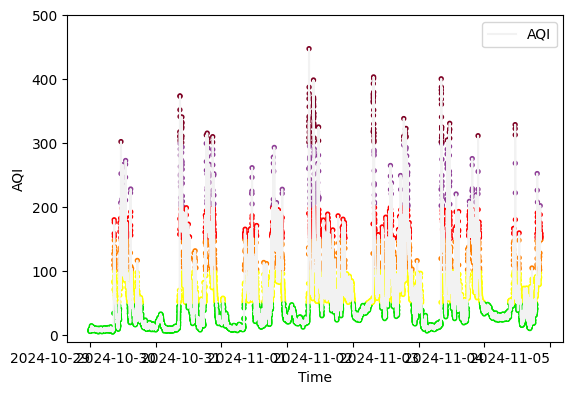

In [3]:
aqi_df = df.loc[
    (df["Time"] >= datetime.datetime.fromisoformat("2024-10-29T00:00:00+08.00")) &
    (df["Time"] < datetime.datetime.fromisoformat("2024-11-05T00:00:00+08.00")) &
    (df["Floor"] == "2") &
    (df["Location"] == "West Hallway") &
    (df["Device"] == "00"),
    ["Time", "AQI"]
].set_index("Time").sort_index()
display_data(aqi_df)
# display(aqi_df)


## West Tower 5th Floor Hallway
November 5, 2024 to November 11, 2024

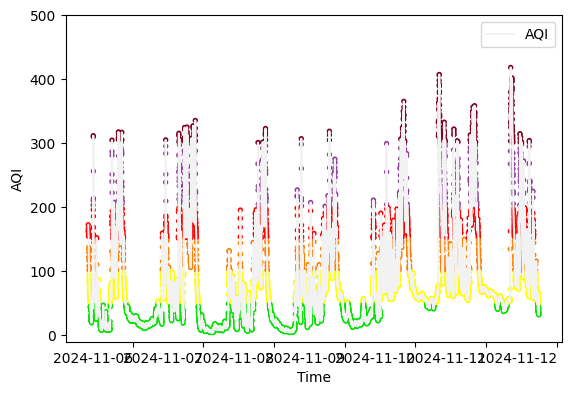

In [4]:
aqi_df = df.loc[
    (df["Time"] >= datetime.datetime.fromisoformat("2024-11-05T00:00:00+08.00")) &
    (df["Time"] < datetime.datetime.fromisoformat("2024-11-12T00:00:00+08.00")) &
    (df["Floor"] == "5") &
    (df["Location"] == "West Hallway") &
    (df["Device"] == "00"),
    ["Time", "AQI"]
].set_index("Time").sort_index()
display_data(aqi_df)
# display(aqi_df)


## East Tower 5th Floor Hallway
November 12, 2024 to November 18, 2024

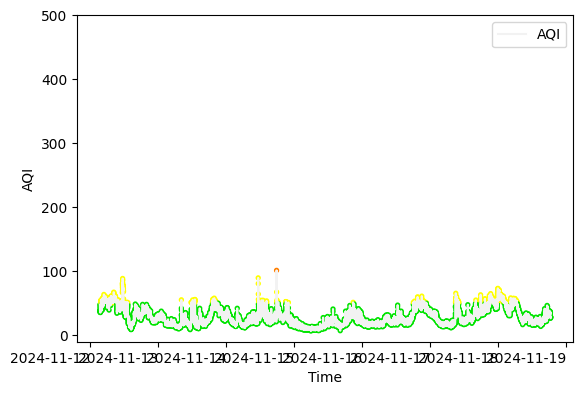

In [5]:
aqi_df = df.loc[
    (df["Time"] >= datetime.datetime.fromisoformat("2024-11-12T00:00:00+08.00")) &
    (df["Time"] < datetime.datetime.fromisoformat("2024-11-19T00:00:00+08.00")) &
    (df["Floor"] == "5") &
    (df["Location"] == "East Hallway") &
    (df["Device"] == "00"),
    ["Time", "AQI"]
].set_index("Time").sort_index()
display_data(aqi_df)
# display(aqi_df)
